### Set up

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import gc
from functions import compute_grand_tfr

In [2]:
base_dir = '/home/p2894/mne_eeg_workshop/ds006777'
derivatives_dir = os.path.join(base_dir, 'derivatives')
results_dir = os.path.join(base_dir, 'results')

if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    print(f"Has successfully created: {results_dir}")
else:
    print("Folder `results` exists. No need to create.")

log_file_path = os.path.join(results_dir, 'TFR_topomap_log.txt')
mne.set_log_file(log_file_path, overwrite=True)

Folder `results` exists. No need to create.


### Parameters for computing TFR

In [3]:
freqs = np.logspace(*np.log10([1, 50]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency

### Topographic maps for AV across five frequency bands (TD)

In [4]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-10*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
#subject_ids = ['sub-10025']
condition = 'AV'
picks = ['eeg']

#### Compute TFR across all channels

**NOTE:** It will take some time (about 6.5 min).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [5]:
grand_power_AV_TD, all_power_AV_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

#### Check TFR data

In [6]:
for i, tfr in enumerate(all_power_AV_TD):
    print(f"Index {i} | Shape: {tfr.data.shape} | Time points: {len(tfr.times)}")

Index 0 | Shape: (64, 100, 141) | Time points: 141
Index 1 | Shape: (64, 100, 141) | Time points: 141
Index 2 | Shape: (64, 100, 141) | Time points: 141
Index 3 | Shape: (64, 100, 141) | Time points: 141
Index 4 | Shape: (64, 100, 141) | Time points: 141
Index 5 | Shape: (64, 100, 141) | Time points: 141
Index 6 | Shape: (64, 100, 141) | Time points: 141
Index 7 | Shape: (64, 100, 141) | Time points: 141
Index 8 | Shape: (64, 100, 141) | Time points: 141
Index 9 | Shape: (64, 100, 141) | Time points: 141
Index 10 | Shape: (64, 100, 141) | Time points: 141
Index 11 | Shape: (64, 100, 141) | Time points: 141
Index 12 | Shape: (64, 100, 141) | Time points: 141
Index 13 | Shape: (64, 100, 141) | Time points: 141
Index 14 | Shape: (64, 100, 141) | Time points: 141
Index 15 | Shape: (64, 100, 141) | Time points: 141
Index 16 | Shape: (64, 100, 141) | Time points: 141
Index 17 | Shape: (64, 100, 141) | Time points: 141
Index 18 | Shape: (64, 100, 141) | Time points: 141
Index 19 | Shape: (64,

#### Save grand TFR file to `results` folder

In [7]:
tfr_file_path = os.path.join(results_dir, 'grand_AV_TD-tfr.h5')
grand_power_AV_TD.save(tfr_file_path, overwrite=True)
#mne.time_frequency.read_tfrs(tfr_file_path)

#### Visualization

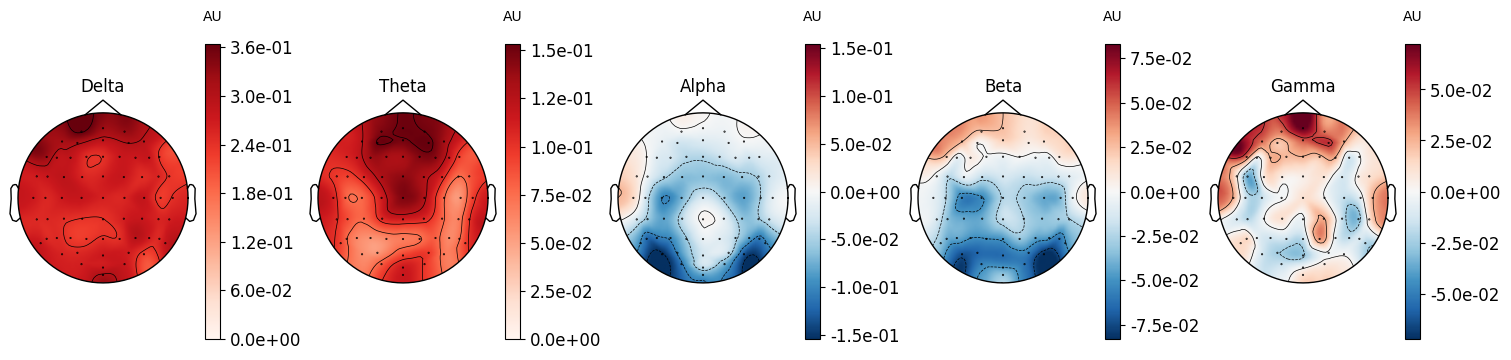

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")

topomap_kw = dict(
    ch_type="eeg",
    tmin=0, 
    tmax=0.9, 
    baseline=(-0.2, 0), 
    mode="logratio",
    #vlim=(-0.3, 0.3), 
    show=False
)

plot_dict = dict(Delta=dict(fmin=1, fmax=4), 
                 Theta=dict(fmin=4, fmax=8), 
                 Alpha=dict(fmin=8, fmax=12), 
                 Beta=dict(fmin=12, fmax=30), 
                 Gamma=dict(fmin=30, fmax=50))

for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    grand_power_AV_TD.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

### Topographic maps for AV across five frequency bands (ASC)

In [9]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-11*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
condition = 'AV'
picks = ['eeg']

#### Compute TFR across all channels

**NOTE:** It will take some time (about 11 min).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [10]:
grand_power_AV_ASC, all_power_AV_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

#### Check TFR data

In [11]:
for i, tfr in enumerate(all_power_AV_ASC):
    print(f"Index {i} | Shape: {tfr.data.shape} | Time points: {len(tfr.times)}")

Index 0 | Shape: (64, 100, 141) | Time points: 141
Index 1 | Shape: (64, 100, 141) | Time points: 141
Index 2 | Shape: (64, 100, 141) | Time points: 141
Index 3 | Shape: (64, 100, 141) | Time points: 141
Index 4 | Shape: (64, 100, 141) | Time points: 141
Index 5 | Shape: (64, 100, 141) | Time points: 141
Index 6 | Shape: (64, 100, 141) | Time points: 141
Index 7 | Shape: (64, 100, 141) | Time points: 141
Index 8 | Shape: (64, 100, 141) | Time points: 141
Index 9 | Shape: (64, 100, 141) | Time points: 141
Index 10 | Shape: (64, 100, 141) | Time points: 141
Index 11 | Shape: (64, 100, 141) | Time points: 141
Index 12 | Shape: (64, 100, 141) | Time points: 141
Index 13 | Shape: (64, 100, 141) | Time points: 141
Index 14 | Shape: (64, 100, 141) | Time points: 141
Index 15 | Shape: (64, 100, 141) | Time points: 141
Index 16 | Shape: (64, 100, 141) | Time points: 141
Index 17 | Shape: (64, 100, 141) | Time points: 141
Index 18 | Shape: (64, 100, 141) | Time points: 141
Index 19 | Shape: (64,

#### Save grand TFR file to `results` folder

In [12]:
tfr_file_path = os.path.join(results_dir, 'grand_AV_ASC-tfr.h5')
grand_power_AV_ASC.save(tfr_file_path, overwrite=True)

#### Visualization

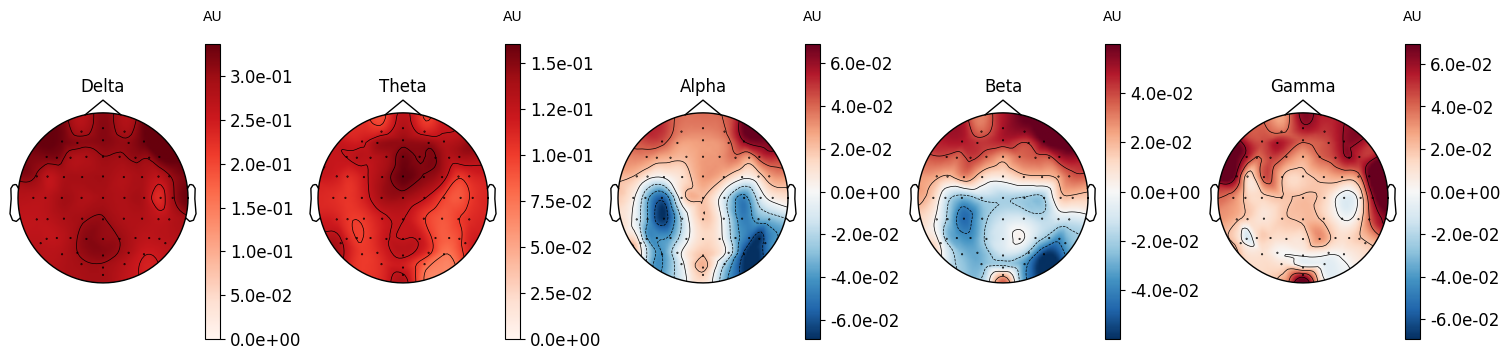

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")

topomap_kw = dict(
    ch_type="eeg",
    tmin=0, 
    tmax=0.9, 
    baseline=(-0.2, 0), 
    mode="logratio",
    #vlim=(-0.3, 0.3), 
    show=False
)

plot_dict = dict(Delta=dict(fmin=1, fmax=4), 
                 Theta=dict(fmin=4, fmax=8), 
                 Alpha=dict(fmin=8, fmax=12), 
                 Beta=dict(fmin=12, fmax=30), 
                 Gamma=dict(fmin=30, fmax=50))

for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    grand_power_AV_ASC.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

### TFR across conditions in TD

In [14]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-10*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
#subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
picks = ['eeg']

**NOTE:** It will take some time (about 5.5 min per cell when running `compute_grand_tfr`).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [15]:
condition = 'A'
grand_power_A_TD, all_power_A_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

In [16]:
tfr_file_path = os.path.join(results_dir, 'grand_A_TD-tfr.h5')
grand_power_A_TD.save(tfr_file_path, overwrite=True)

In [17]:
condition = 'V'
grand_power_V_TD, all_power_V_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

In [18]:
tfr_file_path = os.path.join(results_dir, 'grand_V_TD-tfr.h5')
grand_power_V_TD.save(tfr_file_path, overwrite=True)

### TFR across conditions in ASC

In [19]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-11*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
picks = ['eeg']

In [20]:
condition = 'A'
grand_power_A_ASC, all_power_A_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

In [21]:
tfr_file_path = os.path.join(results_dir, 'grand_A_ASC-tfr.h5')
grand_power_A_ASC.save(tfr_file_path, overwrite=True)

In [22]:
condition = 'V'
grand_power_V_ASC, all_power_V_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

In [23]:
tfr_file_path = os.path.join(results_dir, 'grand_V_ASC-tfr.h5')
grand_power_V_ASC.save(tfr_file_path, overwrite=True)

### Visualization of TFR across experimental conditions for each group

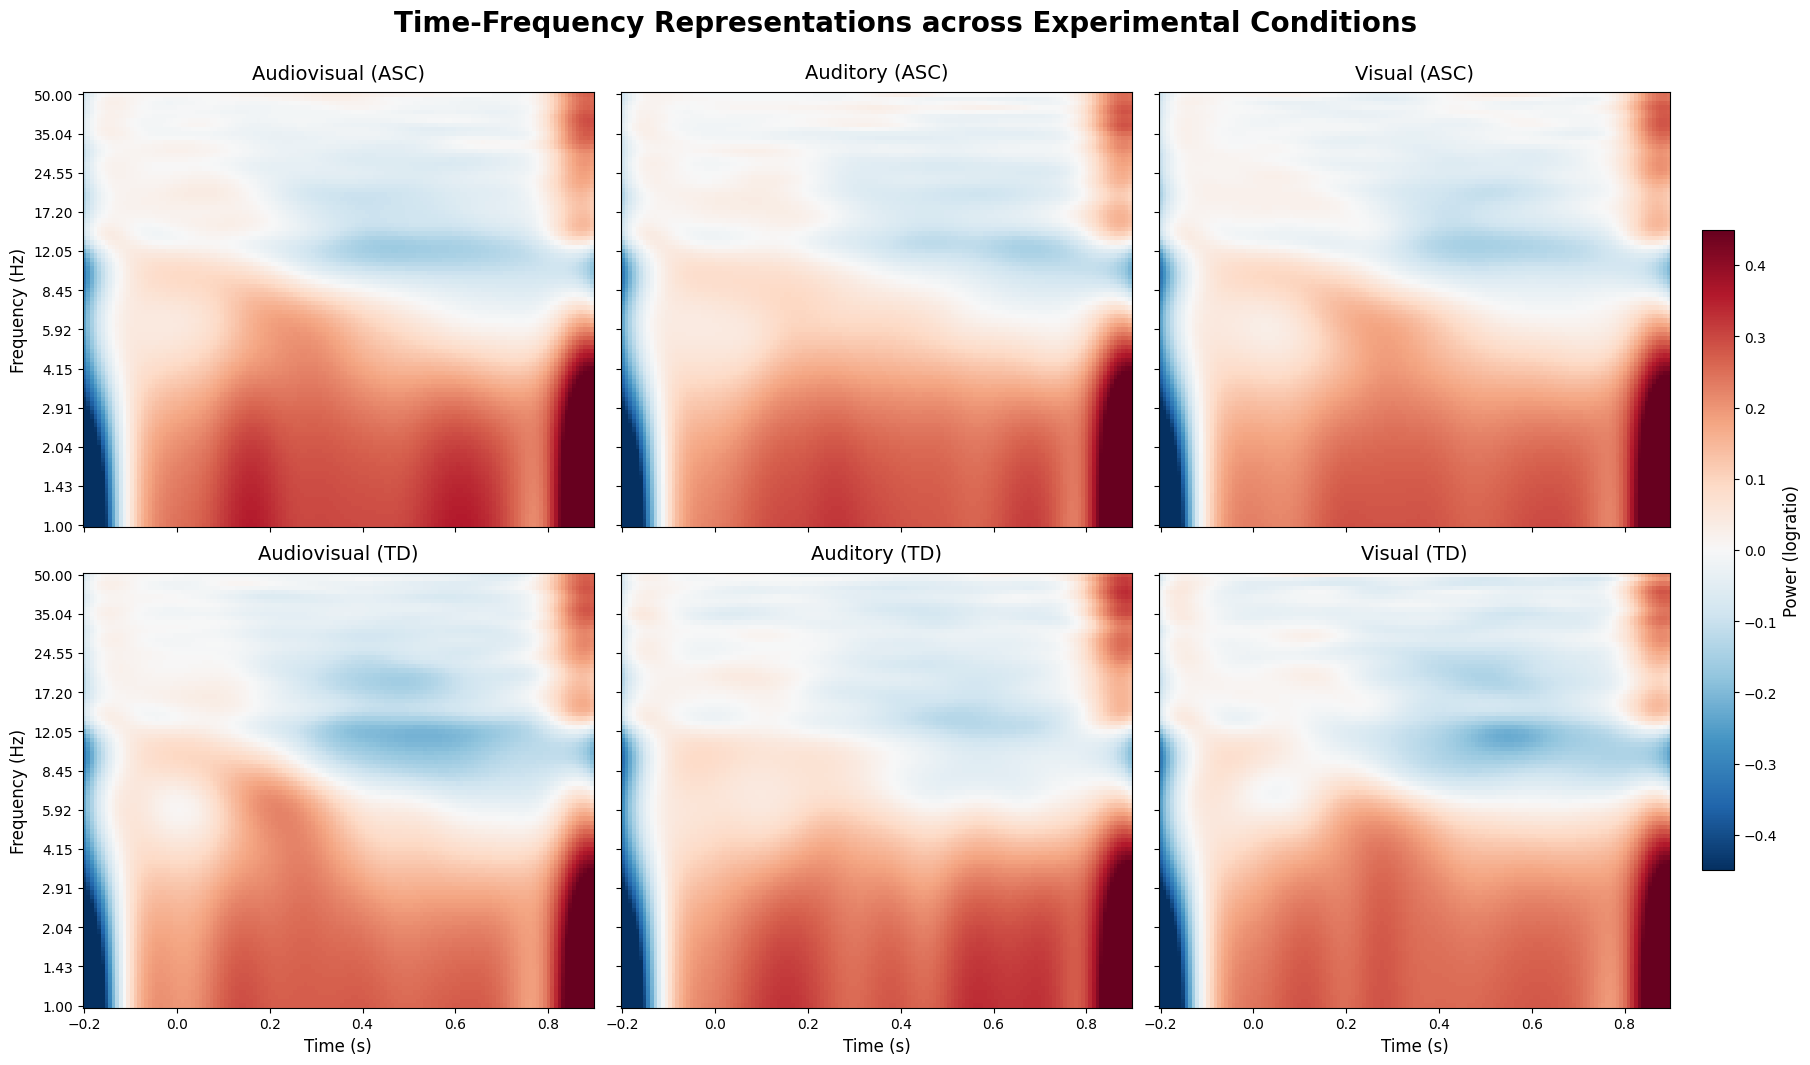

In [36]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), layout="constrained")
#axes = axes.flatten()  # 將 2D 陣列拉平，方便用單一索引跑迴圈

# 假設你把算好的 6 個 Grand Average 物件打包成一個列表與對應標題
tfr_list = [
    grand_power_AV_ASC, grand_power_A_ASC,
    grand_power_V_ASC, grand_power_AV_TD,
    grand_power_A_TD, grand_power_V_TD
]
titles = [
    'Audiovisual (ASC)', 'Auditory (ASC)',
    'Visual (ASC)', 'Audiovisual (TD)',
    'Auditory (TD)', 'Visual (TD)'
]

# 設定統一的色彩範圍上限與下限
vmin, vmax = -0.45, 0.45

# 2. 依序將 TFR 畫進對應的子圖
im = None  # 用來記錄影像物件以生成 colorbar
for i, (tfr, title) in enumerate(zip(tfr_list, titles)):
    # 關鍵：傳入 axes=axes[i], vlim=(vmin, vmax), 且最重要的是 show=False
    # 它會回傳一個包含 matplotlib figure 的列表
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    tfr_fig = tfr.plot(
        picks=roi_channels, 
        baseline=(-0.2, 0), 
        mode="logratio", 
        combine='mean',
        #title=title, 
        vlim=(vmin, vmax),
        axes=ax,  # 指定畫在特定的子圖上
        colorbar=False,
        show=False     # 阻止 MNE 建立獨立的 colorbar 與新視窗
    )
    
    ax.set_title(title, fontsize=14, pad=10)
    
    if col > 0:
        ax.set_ylabel('')      
        ax.set_yticklabels([]) 
    else:
        ax.set_ylabel('Frequency (Hz)', fontsize=12) 

    if row < 1:
        ax.set_xlabel('')      
        ax.set_xticklabels([]) 
    else:
        ax.set_xlabel('Time (s)', fontsize=12)

    # 抓取其中一個 QuadMesh 物件來做全域 colorbar
    if im is None:
        im = ax.collections[0] if ax.collections else ax.images[0]


# 建立全域唯一的共享 colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label('Power (logratio)', fontsize=12)

fig.suptitle('Time-Frequency Representations across Experimental Conditions', fontsize=20, fontweight='bold', y=1.05)

plt.show()
# 3. 移除 MNE 自動幫每個子圖多產生的內建 colorbar Axes（如果有的話）
# 因為 MNE 的 plot 函式有時會在 axes[i] 內部進行複雜切分，若發現版面殘留空白，
# 可以直接使用 matplotlib 的 fig.colorbar 綁定剛剛抓到的影像物件：

# 4. 建立全域唯一的共享 colorbar
#cbar = fig.colorbar(im, ax=axes.tolist(), orientation='vertical', shrink=0.6)
#cbar.set_label('Power (logratio)')

#plt.show()

### TFR for auditory stimuli in ASC

In [ ]:
subject_paths = glob.glob(os.path.join(base_dir, 'sub-11*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])

In [ ]:
all_power_A = []

for subject_id in subject_ids:
        
    epochs_path = os.path.join(derivatives_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_A = epochs['A'] 
        
        power_A = epochs_A.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        

        all_power_A.append(power_A)
        
    except Exception as e:
        print(f"{subject_id} failed to be processed: {e}")
        
    finally:
        if 'epochs' in locals(): del epochs
        if 'epochs_A' in locals(): del epochs_A
        gc.collect()


if len(all_power_A) > 0:
    
    grand_power_A = mne.grand_average(all_power_A)
    
    grand_power_A.plot(
        picks=roi_channels, 
        baseline=(-0.2, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for auditory stimuli (TD) (N={len(all_power_A)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("No data have been read successfully.")

### V (TD)

In [ ]:
subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
all_power_V = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

In [ ]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_V = epochs['V']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_V = epochs_V.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_V.append(power_V)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_V' in locals(): del epochs_V
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_V) > 0:
    print(f"\n正在計算 {len(all_power_V)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_V = mne.grand_average(all_power_V)
    
    # 畫出最終的平均圖
    grand_power_V.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for visual stimuli (TD) (N={len(all_power_V)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### V (ASC)

In [ ]:
subject_ids = ['sub-11038', 'sub-11049', 'sub-11053']
all_power_V = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

In [ ]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_V = epochs['V']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_V = epochs_V.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_V.append(power_V)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_V' in locals(): del epochs_V
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_V) > 0:
    print(f"\n正在計算 {len(all_power_V)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_V = mne.grand_average(all_power_V)
    
    # 畫出最終的平均圖
    grand_power_V.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for visual stimuli (ASC) (N={len(all_power_V)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### AV (TD)

In [ ]:
subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
all_power_AV = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

In [ ]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_AV = epochs['AV']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_AV = epochs_AV.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_AV.append(power_AV)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_AV' in locals(): del epochs_AV
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_AV) > 0:
    print(f"\n正在計算 {len(all_power_AV)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_AV = mne.grand_average(all_power_AV)
    
    # 畫出最終的平均圖
    grand_power_AV.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for audiovisual stimuli (TD) (N={len(all_power_AV)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### AV (ASC)

In [ ]:
subject_ids = ['sub-11038', 'sub-11049', 'sub-11053']
all_power_AV = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

In [ ]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_AV = epochs['AV']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_AV = epochs_AV.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_AV.append(power_AV)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_AV' in locals(): del epochs_AV
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_AV) > 0:
    print(f"\n正在計算 {len(all_power_AV)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_AV = mne.grand_average(all_power_AV)
    
    # 畫出最終的平均圖
    grand_power_AV.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for audiovisual stimuli (ASC) (N={len(all_power_AV)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### A

In [ ]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_A = epochs_A.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

In [ ]:
power.shape

In [ ]:
#power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power") 
power_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for auditory stimuli')

In [ ]:
epochs_A

### V

In [ ]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_V = epochs_V.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

In [ ]:
power_V.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for visual stimuli')

### AV

In [ ]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_AV = epochs_AV.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

In [ ]:
power_AV.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for audiovisual stimuli')

### MSI effect

In [ ]:
power_AV_minus_A = power_AV - power_A

In [ ]:
power_AV_minus_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for MSI effect')

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")

topomap_kw = dict(
    ch_type="eeg",
    tmin=-0.2, 
    tmax=0.9, 
    baseline=(-0.2, 0), 
    mode="logratio",
    vlim=(-0.3, 0.3), 
    show=False
)

plot_dict = dict(Delta=dict(fmin=1, fmax=4), 
                 Theta=dict(fmin=4, fmax=8), 
                 Alpha=dict(fmin=8, fmax=12), 
                 Beta=dict(fmin=13, fmax=30), 
                 Gamma=dict(fmin=30, fmax=50))

for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

In [ ]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0, 10), (0.5, 8)]
)

In [ ]:
# Time-frequency analysis for each quartile 
freqs = np.linspace(*np.array([2, 40]), num=200) #num = step / bin allows a precision of the frequency resolution
n_cycles = freqs / 2  # different number of cycle per frequency
    
# Total power for each quartile
power_A = mne.time_frequency.tfr_morlet(epochs_A, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                            output = 'complex', return_itc=False, decim=1, n_jobs=1, average=False)
# Compute Time-Frequency Representation (TFR) using Morlet wavelets, which operates on Epochs or Evoked objects instead of NumPy arrays.
# https://mne.tools/stable/generated/mne.time_frequency.tfr_morlet.html